# 🌳 Praktikum Machine Learning - Pertemuan 5
## Decision Tree dan Teknik *Pruning*

| | |
|:--|:--|
| **Nama** | Dhani Kurnia Ramdani |
| **NPM** | 202343500139 |
| **Mata Kuliah** | Machine Learning |

---

### 🎯 Tujuan
Memahami bagaimana *Decision Tree* bisa **overfitting** ketika dibiarkan tumbuh penuh, lalu mengendalikannya dengan dua pendekatan *pruning*.

### 🧠 Konsep Singkat

| Teknik | Kapan dilakukan | Cara kerja |
|:--|:--|:--|
| **Tanpa pruning** | - | Pohon tumbuh sampai semua data latih terklasifikasi sempurna. Rawan overfitting. |
| **Pre-pruning** | Saat pohon dibangun | Membatasi pertumbuhan lewat `max_depth` dan `min_samples_leaf`. |
| **Post-pruning (CCP)** | Setelah pohon jadi | *Cost Complexity Pruning*: cabang yang manfaatnya kecil dipangkas. Makin besar `ccp_alpha`, makin kecil pohonnya. |

### 🗺️ Alur Kerja
Persiapan library → Muat dataset → Split data → Latih tiga model → Evaluasi → Visualisasi pohon → **Latihan 1** (grid pre-pruning) → **Latihan 2** (jalur `ccp_alpha`)

---
## 1️⃣ Persiapan Library
Mengimpor `numpy`, `pandas`, dan `matplotlib` untuk data dan grafik, serta `DecisionTreeClassifier`, `plot_tree`, dan metrik evaluasi dari `scikit-learn`.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

---
## 2️⃣ Memuat Dataset
Dataset yang dipakai adalah ***Breast Cancer Wisconsin*** bawaan `scikit-learn`: **569 sampel** dengan **30 fitur** numerik hasil pengukuran sel tumor.

| Kelas | Arti | Jumlah |
|:-:|:--|:-:|
| 0 | *malignant* (ganas) | 212 |
| 1 | *benign* (jinak) | 357 |

> 📌 Kelas cukup seimbang, jadi **akurasi** masih layak dipakai sebagai metrik utama.

In [15]:
data = load_breast_cancer(as_frame=True)

X, y = data.data, data.target

print("Ukuran data:", X.shape)
print("Distribusi kelas:", np.bincount(y))

Ukuran data: (569, 30)
Distribusi kelas: [212 357]


---
## 3️⃣ Membagi Data
Data dibagi **80% latih (455 sampel)** dan **20% uji (114 sampel)**. Parameter `stratify=y` menjaga proporsi kelas tetap sama di kedua bagian, dan `random_state=42` membuat hasil bisa direproduksi.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

---
## 4️⃣ Membangun Tiga Model
Tiga pohon dilatih sebagai pembanding:

| Model | Pengaturan |
|:--|:--|
| 🌲 **Tanpa Pruning** | Parameter bawaan (tumbuh penuh) |
| ✂️ **Pre-Pruning** | `max_depth=4`, `min_samples_leaf=5` |
| 🪓 **Post-Pruning (CCP)** | `ccp_alpha` diambil dari **tengah** jalur `cost_complexity_pruning_path` |

> 💡 `cost_complexity_pruning_path` menghasilkan deretan nilai `ccp_alpha` yang masing-masing menghasilkan pohon lebih kecil. Di sini diambil nilai tengahnya sebagai contoh cepat; **Latihan 2** menelusuri semuanya.

In [ ]:
# Model tanpa pruning (tumbuh penuh)
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

# Model dengan pre-pruning
tree_pruned = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)
tree_pruned.fit(X_train, y_train)

# Model dengan post-pruning (Cost Complexity Pruning)
path = tree_full.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alpha_terpilih = path.ccp_alphas[len(path.ccp_alphas) // 2]

tree_ccp = DecisionTreeClassifier(
    ccp_alpha=ccp_alpha_terpilih,
    random_state=42
)

tree_ccp.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

---
## 5️⃣ Evaluasi: Akurasi Latih vs Uji
Selisih antara akurasi latih dan uji adalah tanda utama **overfitting**.

| Model | Akurasi Latih | Akurasi Uji | Selisih |
|:--|:-:|:-:|:-:|
| Tanpa Pruning | 1,000 | 0,912 | 0,088 |
| Pre-Pruning | 0,976 | 0,921 | 0,055 |
| Post-Pruning (CCP) | 0,978 | **0,930** | 0,048 |

In [ ]:
for nama, model in [
    ("Tanpa Pruning", tree_full),
    ("Pre-Pruning", tree_pruned),
    ("Post-Pruning (CCP)", tree_ccp)
]:
    acc_train = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    acc_test = accuracy_score(
        y_test,
        model.predict(X_test)
    )

    print(
        f"{nama}: Akurasi Train={acc_train:.3f}, "
        f"Akurasi Test={acc_test:.3f}"
    )

Tanpa Pruning: Akurasi Train=1.000, Akurasi Test=0.912
Pre-Pruning: Akurasi Train=0.976, Akurasi Test=0.921
Post-Pruning (CCP): Akurasi Train=0.978, Akurasi Test=0.930


### 📝 Analisis
- Pohon **tanpa pruning** menghafal data latih (akurasi 1,000) tetapi paling lemah di data uji (0,912): ciri khas *overfitting*.
- Kedua teknik pruning **mengorbankan sedikit akurasi latih** (turun ke ±0,977) dan sebagai gantinya **menaikkan akurasi uji** serta mempersempit selisihnya.
- Pada data ini, post-pruning (0,930) sedikit mengungguli pre-pruning (0,921). Namun, selisih 0,009 setara hanya **1 dari 114** sampel uji, jadi jangan menyimpulkan terlalu jauh.

---
## 6️⃣ Visualisasi Pohon
Pohon hasil **pre-pruning** (`max_depth=4`) digambar agar bisa dibaca. Setiap kotak menampilkan aturan pemisahan, nilai `gini`, jumlah sampel, sebaran kelas, dan kelas mayoritas. Warna menunjukkan kelas dominan, dan makin pekat berarti makin murni.

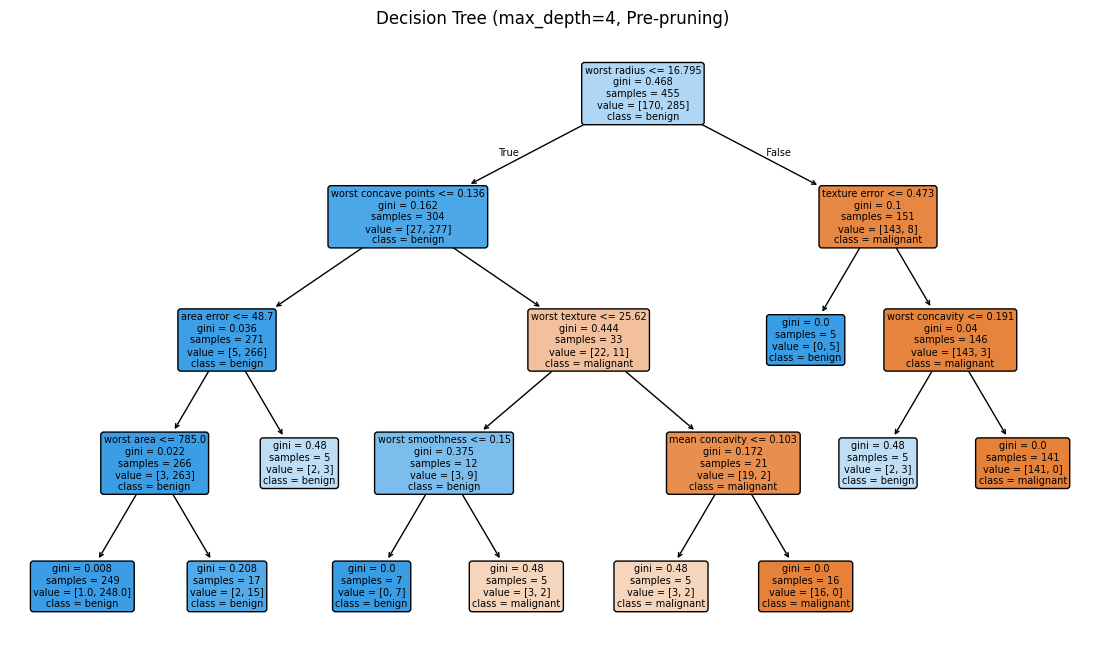

In [ ]:

plt.figure(figsize=(14, 8))
plot_tree(
    tree_pruned,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Decision Tree (max_depth=4, Pre-pruning)")
plt.show()

---
# 🧪 Latihan Praktikum
Dua latihan berikut mengeksplorasi pruning lebih dalam. Data disiapkan ulang di sel berikut supaya bagian latihan bisa dijalankan terpisah.

In [ ]:
# Persiapan data untuk Latihan Praktikum Bab 5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Ukuran data latih:", X_train.shape)
print("Ukuran data uji  :", X_test.shape)

Ukuran data latih: (455, 30)
Ukuran data uji  : (114, 30)


---
## 📌 Latihan 1: Grid Pre-Pruning
**Tugas:** mencoba semua kombinasi `max_depth` ∈ {2, 4, 6, None} dan `min_samples_leaf` ∈ {1, 5, 10}, lalu mencari kombinasi dengan akurasi uji terbaik.

In [ ]:
print(f"{'max_depth':>10s} | {'min_samples_leaf':>16s} | {'Akurasi Test':>12s}")
print("-" * 46)

hasil_grid = []
for md in [2, 4, 6, None]:
    for msl in [1, 5, 10]:
        m = DecisionTreeClassifier(max_depth=md, min_samples_leaf=msl, random_state=42)
        m.fit(X_train, y_train)
        ak = accuracy_score(y_test, m.predict(X_test))
        hasil_grid.append((ak, md, msl))
        print(f"{str(md):>10s} | {msl:16d} | {ak:12.4f}")

terbaik = max(hasil_grid, key=lambda t: t[0])
print(f"\nKombinasi terbaik: max_depth={terbaik[1]}, min_samples_leaf={terbaik[2]} "
      f"-> akurasi test {terbaik[0]:.4f}")

 max_depth | min_samples_leaf | Akurasi Test
----------------------------------------------
         2 |                1 |       0.8947
         2 |                5 |       0.8947
         2 |               10 |       0.9035
         4 |                1 |       0.9386
         4 |                5 |       0.9211
         4 |               10 |       0.9474
         6 |                1 |       0.9123
         6 |                5 |       0.9298
         6 |               10 |       0.9474
      None |                1 |       0.9123
      None |                5 |       0.9298
      None |               10 |       0.9474

Kombinasi terbaik: max_depth=4, min_samples_leaf=10 -> akurasi test 0.9474


Hasil di atas divisualisasikan sebagai *heatmap* agar pola antar-kombinasi mudah dibandingkan (hijau lebih gelap = akurasi lebih tinggi).

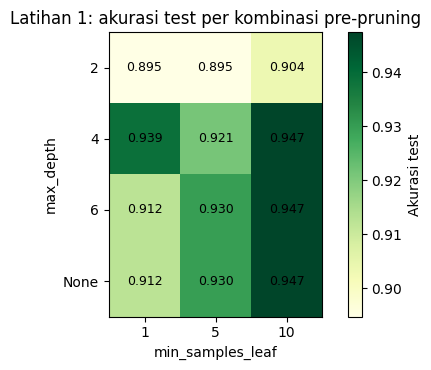

In [ ]:
# Grafik Latihan 1: heatmap akurasi test (max_depth x min_samples_leaf)
import pandas as pd
mat = pd.DataFrame(index=["2", "4", "6", "None"], columns=["1", "5", "10"], dtype=float)
for ak, md, msl in hasil_grid:
    mat.loc[str(md), str(msl)] = ak
plt.figure(figsize=(5.5, 3.8))
im = plt.imshow(mat.values, cmap="YlGn")
plt.xticks(range(3), ["1", "5", "10"])
plt.yticks(range(4), ["2", "4", "6", "None"])
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.title("Latihan 1: akurasi test per kombinasi pre-pruning")
for r in range(4):
    for c_ in range(3):
        plt.text(c_, r, f"{mat.values[r, c_]:.3f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, label="Akurasi test")
plt.tight_layout()
plt.show()

### 📝 Analisis Latihan 1

| Temuan | Penjelasan |
|:--|:--|
| 🏆 **Terbaik: `max_depth=4`, `min_samples_leaf=10`** dengan akurasi **0,9474** | Namun nilai yang sama juga dicapai kombinasi `max_depth=6` dan `None` dengan `min_samples_leaf=10`. |
| 📉 **`max_depth=2` paling rendah** (±0,895-0,904) | Pohon terlalu dangkal sehingga *underfitting*: belum cukup aturan untuk memisahkan kelas. |
| 🔁 **`max_depth=6` dan `None` hasilnya identik** | Kemungkinan pohon tidak pernah tumbuh lebih dalam dari 6 level pada data ini, sehingga batas kedalaman 6 tidak lagi memangkas apa pun. |
| ⬆️ **`min_samples_leaf=10` cenderung terbaik** | Daun dipaksa berisi minimal 10 sampel sehingga aturan yang terlalu spesifik (menghafal noise) tidak terbentuk. |

> ⚠️ **Catatan penting:** kombinasi terbaik dipilih berdasarkan **akurasi data uji**, jadi angka 0,9474 cenderung terlalu optimistis karena data uji ikut dipakai untuk "memilih". Cara yang lebih jujur adalah memilih parameter dengan *cross-validation* pada data latih, lalu data uji dipakai satu kali di akhir.

---
## 📌 Latihan 2: Menelusuri Jalur *Cost Complexity Pruning*
**Tugas:** melatih pohon untuk **setiap** nilai `ccp_alpha` pada jalur pruning, mencatat akurasi uji dan jumlah daun, lalu menentukan `ccp_alpha` optimal.

Hubungan yang perlu diperhatikan: `ccp_alpha` naik → pohon makin kecil (daun berkurang).

 ccp_alpha | Akurasi Test | Jumlah Daun
-----------------------------------------
  0.000000 |       0.9123 |          19
  0.002181 |       0.9211 |          15
  0.002866 |       0.9386 |          12
  0.002930 |       0.9386 |          11
  0.003956 |       0.9386 |          10
  0.004251 |       0.9386 |           9
  0.005024 |       0.9386 |           8
  0.005275 |       0.9298 |           7
  0.005934 |       0.9386 |           6
  0.007641 |       0.9386 |           5
  0.014390 |       0.8947 |           4
  0.020386 |       0.9035 |           3
  0.054334 |       0.9211 |           2
  0.326617 |       0.6316 |           1

Alpha optimal: 0.002866 -> akurasi test 0.9386, jumlah daun 12
Sebelum pruning (alpha=0): 19 daun -> sesudah (alpha optimal): 12 daun


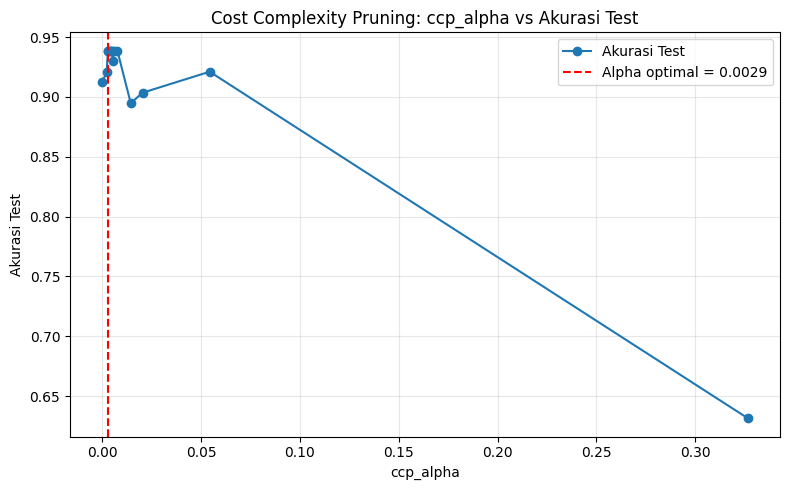

In [ ]:
# Hitung pruning path dulu dari data latih
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas
ak_test_ccp, n_daun = [], []

for a in alphas:
    m = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    m.fit(X_train, y_train)
    ak_test_ccp.append(accuracy_score(y_test, m.predict(X_test)))
    n_daun.append(m.get_n_leaves())

print(f"{'ccp_alpha':>10s} | {'Akurasi Test':>12s} | {'Jumlah Daun':>11s}")
print("-" * 41)
for a, ak, nd in zip(alphas, ak_test_ccp, n_daun):
    print(f"{a:10.6f} | {ak:12.4f} | {nd:11d}")

idx_opt = int(np.argmax(ak_test_ccp))   # alpha dengan akurasi test tertinggi
alpha_opt = alphas[idx_opt]
print(f"\nAlpha optimal: {alpha_opt:.6f} -> akurasi test {ak_test_ccp[idx_opt]:.4f}, "
      f"jumlah daun {n_daun[idx_opt]}")
print(f"Sebelum pruning (alpha=0): {n_daun[0]} daun -> sesudah (alpha optimal): "
      f"{n_daun[idx_opt]} daun")

plt.figure(figsize=(8, 5))
plt.plot(alphas, ak_test_ccp, marker="o", label="Akurasi Test")
plt.axvline(alpha_opt, color="red", linestyle="--",
            label=f"Alpha optimal = {alpha_opt:.4f}")
plt.xlabel("ccp_alpha")
plt.ylabel("Akurasi Test")
plt.title("Cost Complexity Pruning: ccp_alpha vs Akurasi Test")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 📝 Analisis Latihan 2

| Temuan | Penjelasan |
|:--|:--|
| ✂️ **`ccp_alpha` optimal = 0,002866** | Akurasi uji 0,9386 dengan **12 daun**, turun dari **19 daun** sebelum pruning (akurasi 0,9123). |
| 🟢 **Rentang stabil** | Akurasi bertahan di 0,9386 untuk pohon dengan 5 sampai 12 daun. Pohon sekecil 5 daun sudah sebaik pohon 12 daun. |
| 🔴 **Pemangkasan berlebihan** | Pada 4 sampai 2 daun akurasi turun (0,8947 → 0,9211), dan pada **1 daun** (hanya akar) anjlok ke 0,6316 karena model hanya menebak satu kelas. |

**Pola kurva:** akurasi naik saat pohon yang kompleks dipangkas (mengurangi overfitting), mendatar di tengah, lalu jatuh ketika pohon terlalu kecil (*underfitting*), yaitu pola klasik pertukaran bias-varians.

> ⚠️ Sama seperti Latihan 1, `alpha_opt` dipilih memakai akurasi **data uji**. Karena banyak alpha yang menghasilkan akurasi sama (0,9386), memilih satu yang "terbaik" dari selisih sekecil 1 sampel itu sebagian besar kebetulan. Alpha yang lebih kuat secara metodologi adalah yang dipilih lewat *cross-validation*.

---
## ✅ Kesimpulan Akhir

1. **Pohon tanpa pruning overfitting:** akurasi latih 1,000 namun uji hanya 0,912.
2. **Pre-pruning dan post-pruning sama-sama efektif** mengurangi overfitting; akurasi uji naik ke 0,921 (pre) dan 0,930 (post) dengan model yang jauh lebih sederhana.
3. **Parameter yang terlalu ketat merugikan:** `max_depth=2` dan `ccp_alpha` besar menyebabkan *underfitting*. Titik terbaik ada di tengah.
4. **Keterbatasan evaluasi:** data uji hanya 114 sampel (1 sampel ≈ 0,009 akurasi) dan parameter dipilih berdasarkan data uji itu sendiri, sehingga perbedaan kecil antar-konfigurasi sebaiknya tidak dianggap pasti. Validasi silang akan memberi kesimpulan yang lebih kokoh.